# Analytical and Normalized Sensitivity Analysis of Wall Overturning

## 1. Executive Summary & Objective

In the reference wall overturning study (`run_overturning_wall.ipynb`), a single specific wall geometry ($B=2.88\text{ m}, H_1=0.81\text{ m}, H_2=2.253\text{ m}, W=110.8\text{ kN}$) was analyzed across six foundation scour cases.

This notebook develops a comprehensive **analytical sensitivity and normalization framework** that:
1. **Formulates the exact closed-form analytical equations** for critical capacity $F_{cr}$, post-peak rocking equilibrium $F(\theta)$, limit rotation angle $\theta_0$, kinematic displacements $(u_y, u_z)$, and overturning work $U_{max}$.
2. **Establishes a universal non-dimensional normalization scheme**, proving that the entire overturning problem collapses from 6 dimensional parameters $(d_1, d_2, H_1, H_2, W, B)$ into just **3 dimensionless governing variables**:
   - Remaining support ratio $r = b/B \in (0.5, 1.0]$
   - Slenderness / aspect ratio $\lambda = H_2 / B$
   - Relative center of gravity elevation $h_G = H_1 / H_2$
3. **Derives exact analytical gradients and elasticities** ($S(y, x) = \frac{x}{y}\frac{\partial y}{\partial x}$) to rank parameter dominance via Tornado charts.
4. **Executes multi-dimensional parameter sweeps**, generating stability phase diagrams, energy landscapes, and global variance-based Sobol sensitivity indices.

## 2. Governing Analytical Equations & Derivations

Consider a wall and foundation of total weight $W$, foundation width $B$, center of gravity at $(y_G=0, H_1)$ above the foundation base, and vertical live load $F$ applied at the scoured edge ($y_F = -B/2$, elevation $H_2$).

When scour reduces the remaining support to width $b$ (support ratio $r = b/B$), the scour-front pivot is located at:
$$y_p = -\frac{B}{2} + B(1 - r) = B(0.5 - r)$$

The two moment arms relative to the pivot are:
$$d_1 = y_G - y_p = B(r - 0.5), \qquad d_2 = y_p - y_F = B(1 - r)$$

### 2.1 Critical Overturning Capacity ($F_{cr}$ at $\theta = 0$)
Taking moment equilibrium about the pivot at zero rotation:
$$\sum M_p = 0 \implies F_{cr} d_2 = W d_1 \implies F_{cr} = W \frac{d_1}{d_2} = W \frac{r - 0.5}{1 - r}$$

### 2.2 Post-Peak Equilibrium Path ($F(\theta)$)
As the structure rocks outward by an angle $\theta \ge 0$:
- Restoring arm of weight: $d_1(\theta) = d_1 \cos\theta - H_1 \sin\theta$
- Overturning arm of vertical load: $d_2(\theta) = d_2 \cos\theta + H_2 \sin\theta$

$$F(\theta) = W \frac{d_1 \cos\theta - H_1 \sin\theta}{d_2 \cos\theta + H_2 \sin\theta}$$

### 2.3 Zero-Load Limit Rotation Angle ($\theta_0$)
The restoring moment drops to zero when the center of gravity aligns vertically above the pivot:
$$d_1 \cos\theta_0 - H_1 \sin\theta_0 = 0 \implies \tan\theta_0 = \frac{d_1}{H_1} \implies \theta_0 = \arctan\left(\frac{d_1}{H_1}\right)$$

### 2.4 Initial Softening Slope ($K_{	heta,0}$)
$$\left.\frac{dF}{d\theta}\right|_{\theta=0} = -W \left[\frac{H_1 d_2 + H_2 d_1}{d_2^2}\right] = -F_{cr} \left(\frac{H_1}{d_1} + \frac{H_2}{d_2}\right)$$

### 2.5 Overturning Work & Energy Capacity ($U_{max}$)
$$U_{max} = \int_0^{\theta_0} W (d_1 \cos\theta - H_1 \sin\theta) d\theta = W H_1 (\sec\theta_0 - 1) = W \left(\sqrt{d_1^2 + H_1^2} - H_1\right)$$

## 3. Universal Non-Dimensional Normalization Formulation

Dividing all length scales by the total foundation breadth $B$, and normalizing load by self-weight $W$, we define:
$$\tilde{d}_1 = \frac{d_1}{B} = r - 0.5, \qquad \tilde{d}_2 = \frac{d_2}{B} = 1 - r$$
$$\lambda = \frac{H_2}{B} \quad (\text{Aspect Ratio / Slenderness}), \qquad h_G = \frac{H_1}{H_2} \quad (\text{Relative Centroid Height})$$

The normalized governing equations become:

| Dimensional Equation | Normalized Non-Dimensional Equation | Dimensionless Parameters |
| :--- | :--- | :--- |
| $F_{cr} = W \frac{d_1}{d_2}$ | $\frac{F_{cr}}{W} = \frac{r - 0.5}{1 - r}$ | $r$ |
| $\theta_0 = \arctan(d_1 / H_1)$ | $\theta_0 = \arctan\left(\frac{r - 0.5}{h_G \lambda}\right)$ | $r, \lambda, h_G$ |
| $F(\theta) = W \frac{d_1\cos\theta - H_1\sin\theta}{d_2\cos\theta + H_2\sin\theta}$ | $\frac{F(\theta)}{W} = \frac{(r - 0.5)\cos\theta - h_G \lambda \sin\theta}{(1 - r)\cos\theta + \lambda \sin\theta}$ | $r, \lambda, h_G, \theta$ |
| $u_y(\theta) = H_2\sin\theta - d_2(1 - \cos\theta)$ | $\frac{u_y(\theta)}{B} = \lambda \sin\theta - (1 - r)(1 - \cos\theta)$ | $r, \lambda, \theta$ |
| $U_{max} = W(\sqrt{d_1^2 + H_1^2} - H_1)$ | $\frac{U_{max}}{W B} = h_G \lambda \left(\sqrt{1 + \left(\frac{r - 0.5}{h_G \lambda}\right)^2} - 1\right)$ | $r, \lambda, h_G$ |

Furthermore, normalizing force by peak capacity $F_{cr}$ yields the **universal degradation profile** $\Phi(\theta)$:
$$\Phi(\theta) = \frac{F(\theta)}{F_{cr}} = \frac{1 - \eta_1 \tan\theta}{1 + \eta_2 \tan\theta}, \qquad \eta_1 = \frac{H_1}{d_1} = \frac{1}{\tan\theta_0}, \quad \eta_2 = \frac{H_2}{d_2}$$

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add local module path
module_path = Path(".").resolve()
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))

from analytical_model import (
    make_wall_system,
    evaluate_scour_scenario,
    critical_force,
    limit_rotation_angle,
    post_peak_force,
    initial_softening_slope,
    overturning_work_capacity,
    normalized_critical_force,
    normalized_limit_rotation,
    normalized_post_peak_curve,
    relative_capacity_degradation,
    normalized_overturning_energy,
    sensitivity_critical_force,
    sensitivity_limit_rotation,
    sensitivity_support_ratio,
    sensitivity_post_peak_path,
    one_at_a_time_sweep,
    grid_2d_sweep,
    compute_sobol_indices_mc,
)

# Set publication plot styling
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "lines.linewidth": 2.0,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})
print("Analytical Modeling Engine Successfully Loaded.")

Analytical Modeling Engine Successfully Loaded.


## 4. Baseline Case Evaluation (Validation with Notebook Geometry)

We instantiate the exact geometry from `run_overturning_wall.ipynb` and evaluate the 6 scour scenarios.

In [2]:
baseline_system = make_wall_system(
    foundation_length_x_m=1.398,
    foundation_breadth_y_m=2.88,
    foundation_height_z_m=0.758,
    foundation_gamma_kn_m3=22.4,
    wall_length_x_m=0.44,
    wall_breadth_y_m=2.88,
    wall_height_z_m=1.495,
    wall_gamma_kn_m3=22.4,
)

support_ratios = [0.9375, 0.8750, 0.8125, 0.7500, 0.6875, 0.6250]
scenarios = [evaluate_scour_scenario(baseline_system, r) for r in support_ratios]

table_data = []
for sc in scenarios:
    table_data.append({
        "b/B": f"{sc.support_ratio:.4f}",
        "Scour s [m]": f"{sc.scoured_width:.3f}",
        "d1 [m]": f"{sc.d1:.3f}",
        "d2 [m]": f"{sc.d2:.3f}",
        "Fcr [kN]": f"{sc.f_cr:.3f}",
        "Fcr/W [-]": f"{sc.f_cr / baseline_system.total_weight:.3f}",
        "theta_0 [deg]": f"{sc.theta_0_deg:.3f}",
        "U_max [kN*m]": f"{sc.max_energy_kn_m:.3f}",
    })

df_baseline = pd.DataFrame(table_data)
print(f"Total Weight W = {baseline_system.total_weight:.3f} kN")
print(f"Centroid Height H1 = {baseline_system.centroid_h1:.4f} m")
print(f"Load Height H2 = {baseline_system.load_elevation_h2:.4f} m")
print(f"Aspect Ratio lambda = {baseline_system.aspect_ratio_lambda:.4f}")
print(f"Relative Centroid h_G = {baseline_system.relative_centroid_hg:.4f}\n")
df_baseline

Total Weight W = 110.798 kN
Centroid Height H1 = 0.8105 m
Load Height H2 = 2.2530 m
Aspect Ratio lambda = 0.7823
Relative Centroid h_G = 0.3597



,b/B,Scour s [m],d1 [m],d2 [m],Fcr [kN],Fcr/W [-],theta_0 [deg],U_max [kN*m]
0,0.9375,0.180,1.260,0.180,775.588,7.000,57.250,76.195
1,0.8750,0.360,1.080,0.360,332.395,3.000,53.115,59.811
2,0.8125,0.540,0.900,0.540,184.664,1.667,47.997,44.394
3,0.7500,0.720,0.720,0.720,110.798,1.000,41.618,30.318
4,0.6875,0.900,0.540,0.900,66.479,0.600,33.675,18.107
5,0.6250,1.080,0.360,1.080,36.933,0.333,23.951,8.460


## 5. Universal Normalized Curves & Phase Behavior

Plotting the universal non-dimensional response curves demonstrates that all geometric cases follow single invariant master curves.

<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_151511/2062427670.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(hat_thetas, phi, color=color, label=f"b/B={sc.support_ratio:.4f} ($\eta_1$={eta1:.2f}, $\eta_2$={eta2:.2f})")
/tmp/ipykernel_151511/2062427670.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(hat_thetas, phi, color=color, label=f"b/B={sc.support_ratio:.4f} ($\eta_1$={eta1:.2f}, $\eta_2$={eta2:.2f})")


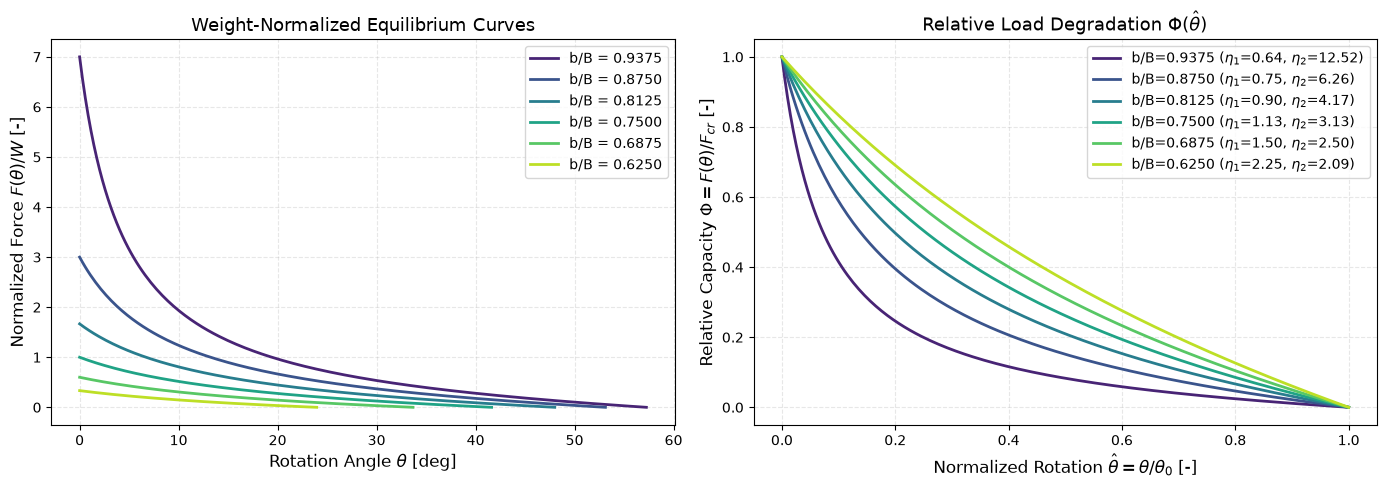

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Normalized post-peak curves F(theta) / W
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(scenarios)))
for sc, color in zip(scenarios, colors):
    thetas_rad = np.linspace(0, sc.theta_0_rad, 200)
    f_norm = normalized_post_peak_curve(
        thetas_rad, sc.support_ratio, baseline_system.aspect_ratio_lambda, baseline_system.relative_centroid_hg
    )
    ax1.plot(np.degrees(thetas_rad), f_norm, color=color, label=f"b/B = {sc.support_ratio:.4f}")

ax1.set_xlabel(r"Rotation Angle $\theta$ [deg]")
ax1.set_ylabel(r"Normalized Force $F(\theta) / W$ [-]")
ax1.set_title("Weight-Normalized Equilibrium Curves")
ax1.grid(True)
ax1.legend()

# 2. Universal degradation Phi(hat_theta)
hat_thetas = np.linspace(0, 1.0, 200)
for sc, color in zip(scenarios, colors):
    thetas_rad = hat_thetas * sc.theta_0_rad
    eta1 = baseline_system.centroid_h1 / sc.d1
    eta2 = baseline_system.load_elevation_h2 / sc.d2
    phi = relative_capacity_degradation(thetas_rad, eta1, eta2)
    ax2.plot(hat_thetas, phi, color=color, label=f"b/B={sc.support_ratio:.4f} ($\eta_1$={eta1:.2f}, $\eta_2$={eta2:.2f})")

ax2.set_xlabel(r"Normalized Rotation $\hat{\theta} = \theta / \theta_0$ [-]")
ax2.set_ylabel(r"Relative Capacity $\Phi = F(\theta) / F_{cr}$ [-]")
ax2.set_title(r"Relative Load Degradation $\Phi(\hat{\theta})$")
ax2.grid(True)
ax2.legend()

fig.tight_layout()
plt.show()

## 6. Analytical Sensitivity Analysis & Elasticity Tornado Charts

### 6.1 Exact Partial Derivatives
- Critical Load Elasticities: $S(F_{cr}, d_1) = +1.0$, $S(F_{cr}, d_2) = -1.0$, $S(F_{cr}, W) = +1.0$, $S(F_{cr}, H_1) = 0.0$, $S(F_{cr}, H_2) = 0.0$.
- Limit Angle Elasticities: $S(\theta_0, d_1) = +\frac{\sin(2\theta_0)}{2\theta_0}$, $S(\theta_0, H_1) = -\frac{\sin(2\theta_0)}{2\theta_0}$.
- Support Ratio Elasticity: $S(F_{cr}, r) = \frac{0.5 r}{(r - 0.5)(1 - r)}$.

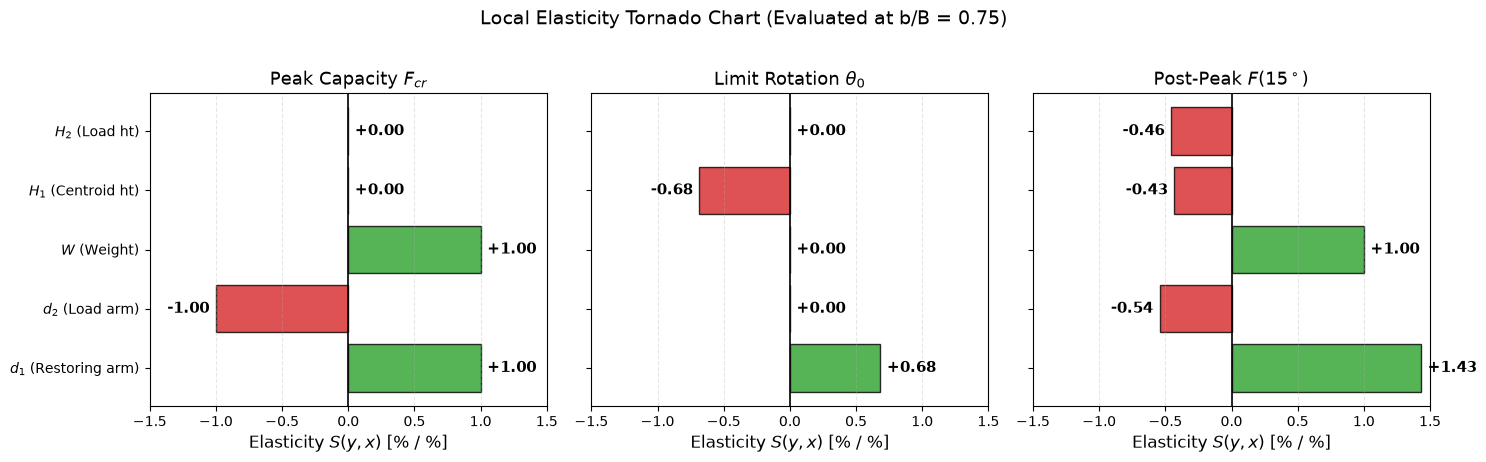

In [4]:
sc_mid = scenarios[3]  # b/B = 0.75
w_val = baseline_system.total_weight
d1_val = sc_mid.d1
d2_val = sc_mid.d2
h1_val = baseline_system.centroid_h1
h2_val = baseline_system.load_elevation_h2

sens_fcr = sensitivity_critical_force(w_val, d1_val, d2_val)
sens_th0 = sensitivity_limit_rotation(d1_val, h1_val)
sens_path_15 = sensitivity_post_peak_path(np.radians(15.0), w_val, d1_val, d2_val, h1_val, h2_val)

params = ["$d_1$ (Restoring arm)", "$d_2$ (Load arm)", "$W$ (Weight)", "$H_1$ (Centroid ht)", "$H_2$ (Load ht)"]
elas_fcr = [sens_fcr["elasticity_d1"], sens_fcr["elasticity_d2"], sens_fcr["elasticity_W"], sens_fcr["elasticity_H1"], sens_fcr["elasticity_H2"]]
elas_th0 = [sens_th0["elasticity_d1"], sens_th0["elasticity_d2"], sens_th0["elasticity_W"], sens_th0["elasticity_H1"], sens_th0["elasticity_H2"]]
elas_f15 = [sens_path_15["elasticity_d1"], sens_path_15["elasticity_d2"], sens_path_15["elasticity_W"], sens_path_15["elasticity_H1"], sens_path_15["elasticity_H2"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
y_pos = np.arange(len(params))

for ax, elas, title in zip(axes, [elas_fcr, elas_th0, elas_f15], [r"Peak Capacity $F_{cr}$", r"Limit Rotation $\theta_0$", r"Post-Peak $F(15^\circ)$"]):
    colors_bar = ["tab:green" if e > 0 else "tab:red" if e < 0 else "tab:gray" for e in elas]
    ax.barh(y_pos, elas, color=colors_bar, alpha=0.8, edgecolor="black")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params if ax == axes[0] else [])
    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_xlabel("Elasticity $S(y, x)$ [% / %]")
    ax.set_title(title)
    ax.set_xlim([-1.5, 1.5])
    ax.grid(True, axis="x")
    for i, v in enumerate(elas):
        ax.text(v + (0.05 if v >= 0 else -0.05), i, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontweight="bold")

fig.suptitle(f"Local Elasticity Tornado Chart (Evaluated at b/B = {sc_mid.support_ratio:.2f})", y=1.02)
fig.tight_layout()
plt.show()

## 7. One-At-A-Time (OAT) Parametric Sensitivity Sweeps (Spider Plots)

Sweeping each variable across $\pm 40\%$ reveals non-linear scaling behaviors.

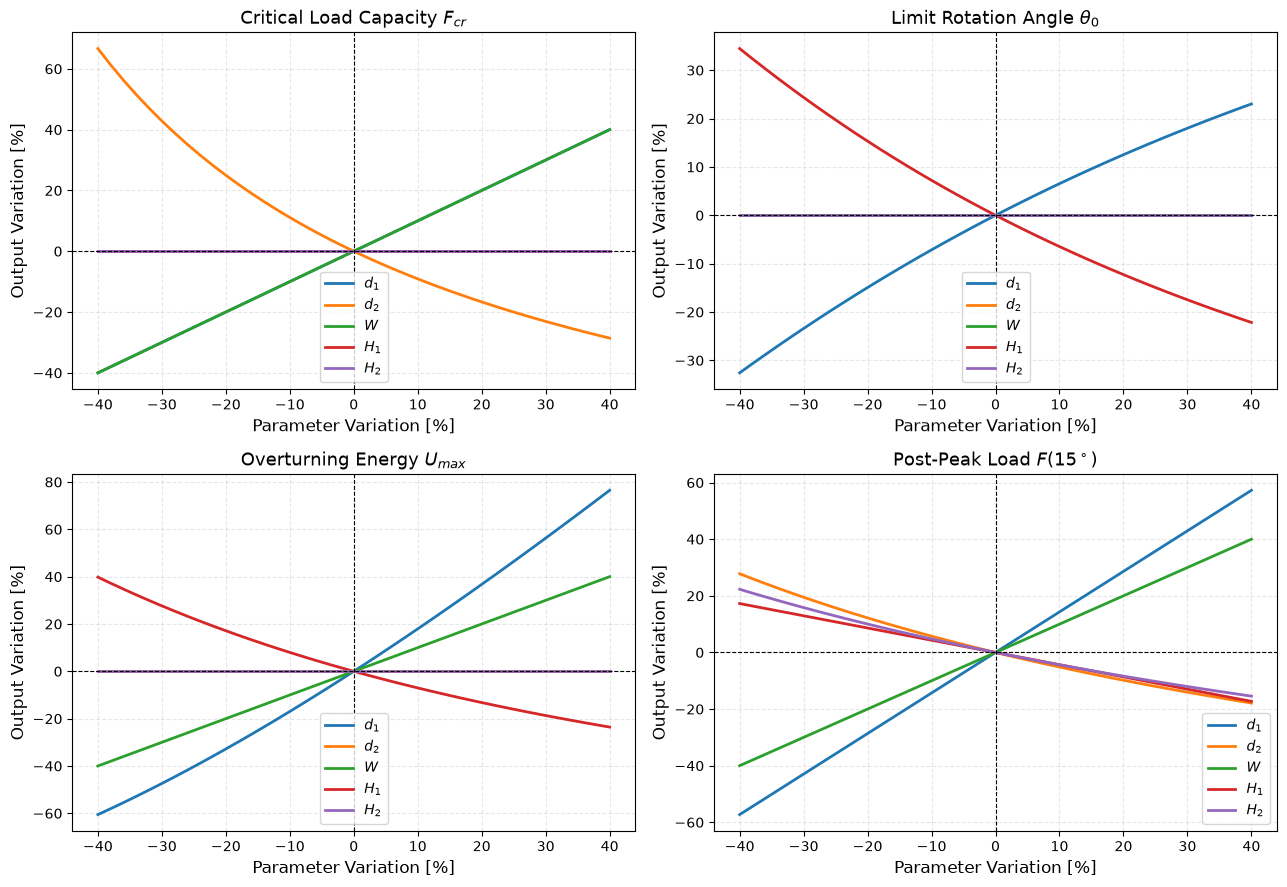

In [5]:
var_pcts = np.linspace(-40.0, 40.0, 41)
base_dict = {"d1": sc_mid.d1, "d2": sc_mid.d2, "W": w_val, "H1": h1_val, "H2": h2_val}

def eval_kpis(p):
    return {
        "F_cr": critical_force(p["W"], p["d1"], p["d2"]),
        "theta_0": float(np.degrees(limit_rotation_angle(p["d1"], p["H1"]))),
        "U_max": overturning_work_capacity(p["W"], p["d1"], p["H1"]),
        "F_15deg": post_peak_force(np.radians(15.0), p["W"], p["d1"], p["d2"], p["H1"], p["H2"]),
    }

oat_results = one_at_a_time_sweep(base_dict, var_pcts, eval_kpis)
base_kpis = eval_kpis(base_dict)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.ravel()
kpi_keys = ["F_cr", "theta_0", "U_max", "F_15deg"]
kpi_titles = [r"Critical Load Capacity $F_{cr}$", r"Limit Rotation Angle $\theta_0$", r"Overturning Energy $U_{max}$", r"Post-Peak Load $F(15^\circ)$"]
plot_colors = {"d1": "tab:blue", "d2": "tab:orange", "W": "tab:green", "H1": "tab:red", "H2": "tab:purple"}
labels = {"d1": "$d_1$", "d2": "$d_2$", "W": "$W$", "H1": "$H_1$", "H2": "$H_2$"}

for ax, kpi, title in zip(axes_flat, kpi_keys, kpi_titles):
    base_val = base_kpis[kpi]
    for p_name in base_dict:
        rel_response = ((oat_results[p_name][kpi] - base_val) / base_val) * 100.0
        ax.plot(var_pcts, rel_response, color=plot_colors[p_name], label=labels[p_name])
    ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Parameter Variation [%]")
    ax.set_ylabel("Output Variation [%]")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

fig.tight_layout()
plt.show()

## 8. Stability Phase Diagrams in $(r, \lambda)$ Space

The 2D contour maps below illustrate the interaction between remaining support ratio $r = b/B$ and wall slenderness $\lambda = H_2 / B$.

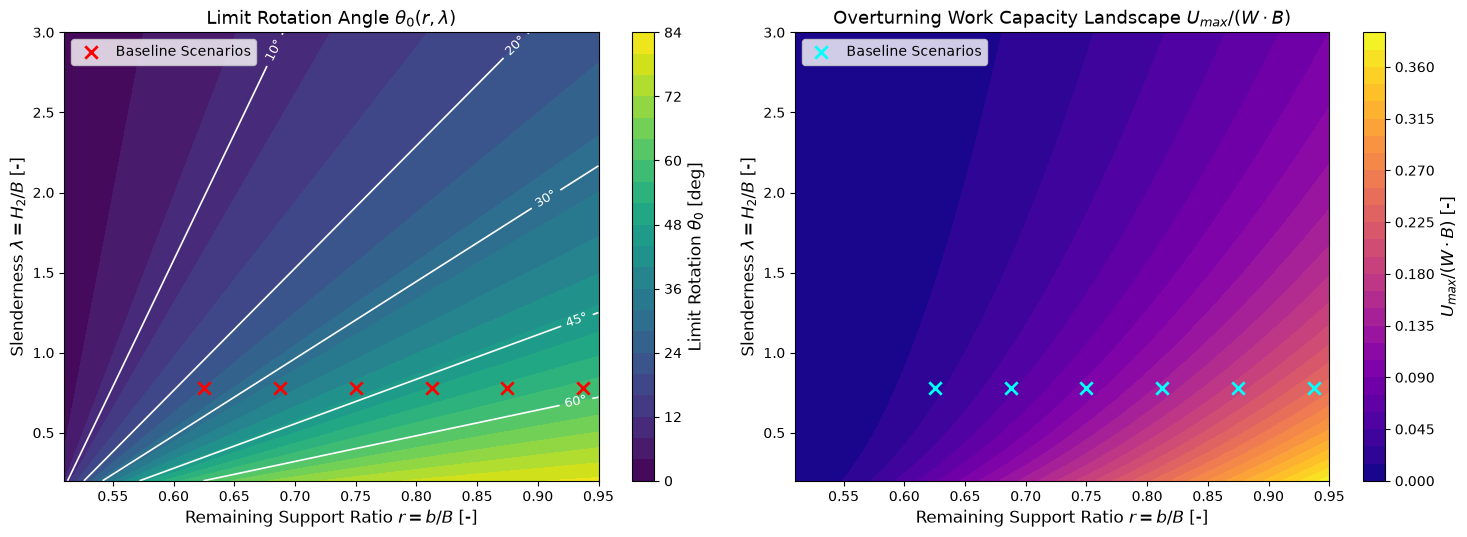

In [6]:
r_grid = np.linspace(0.51, 0.95, 200)
lam_grid = np.linspace(0.2, 3.0, 200)
R_mesh, Lam_mesh = np.meshgrid(r_grid, lam_grid)

Theta0_mesh = np.degrees(normalized_limit_rotation(R_mesh, Lam_mesh, baseline_system.relative_centroid_hg))
Energy_mesh = normalized_overturning_energy(R_mesh, Lam_mesh, baseline_system.relative_centroid_hg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

c1 = ax1.contourf(R_mesh, Lam_mesh, Theta0_mesh, levels=25, cmap="viridis")
c1_lines = ax1.contour(R_mesh, Lam_mesh, Theta0_mesh, levels=[10, 20, 30, 45, 60], colors="white", linewidths=1.2)
ax1.clabel(c1_lines, inline=True, fmt="%1.0f°", fontsize=9)
fig.colorbar(c1, ax=ax1, label=r"Limit Rotation $\theta_0$ [deg]")
ax1.set_xlabel(r"Remaining Support Ratio $r = b/B$ [-]")
ax1.set_ylabel(r"Slenderness $\lambda = H_2 / B$ [-]")
ax1.set_title(r"Limit Rotation Angle $\theta_0(r, \lambda)$")
ax1.scatter([s.support_ratio for s in scenarios], [baseline_system.aspect_ratio_lambda]*len(scenarios),
            color="red", marker="x", s=80, label="Baseline Scenarios", zorder=5)
ax1.legend(loc="upper left")

c2 = ax2.contourf(R_mesh, Lam_mesh, Energy_mesh, levels=25, cmap="plasma")
fig.colorbar(c2, ax=ax2, label=r"$U_{max} / (W \cdot B)$ [-]")
ax2.set_xlabel(r"Remaining Support Ratio $r = b/B$ [-]")
ax2.set_ylabel(r"Slenderness $\lambda = H_2 / B$ [-]")
ax2.set_title(r"Overturning Work Capacity Landscape $U_{max} / (W \cdot B)$")
ax2.scatter([s.support_ratio for s in scenarios], [baseline_system.aspect_ratio_lambda]*len(scenarios),
            color="cyan", marker="x", s=80, label="Baseline Scenarios", zorder=5)
ax2.legend(loc="upper left")

fig.tight_layout()
plt.show()

## 9. Global Sobol Sensitivity Analysis (Variance Decomposition)

Monte Carlo Saltelli sampling evaluates first-order ($S_i$) and total-order ($S_{Ti}$) indices across broad parameter ranges.

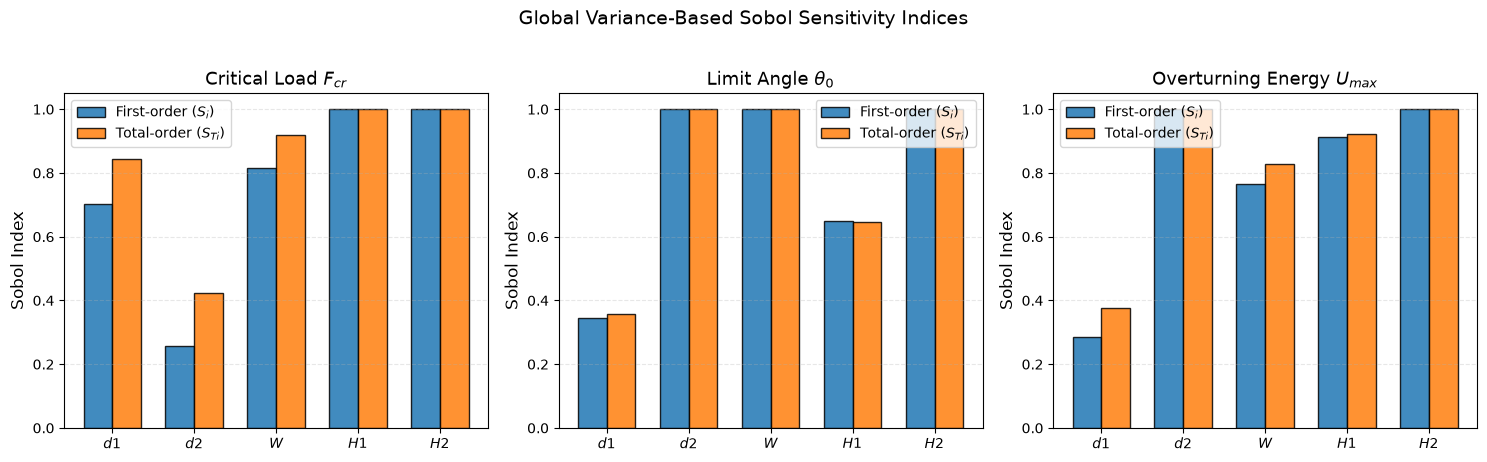

In [7]:
sobol_bounds = {
    "d1": (0.2, 1.4),
    "d2": (0.1, 1.4),
    "W": (50.0, 200.0),
    "H1": (0.4, 1.5),
    "H2": (1.0, 4.0),
}

sobol_fcr = compute_sobol_indices_mc(sobol_bounds, lambda X: X[:, 2] * X[:, 0] / X[:, 1], n_samples=30000, seed=42)
sobol_th0 = compute_sobol_indices_mc(sobol_bounds, lambda X: np.degrees(np.arctan2(X[:, 0], X[:, 3])), n_samples=30000, seed=42)
sobol_umax = compute_sobol_indices_mc(sobol_bounds, lambda X: X[:, 2] * (np.sqrt(X[:, 0]**2 + X[:, 3]**2) - X[:, 3]), n_samples=30000, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
param_keys = list(sobol_bounds.keys())
x_indices = np.arange(len(param_keys))
width = 0.35

for ax, sobol_dict, title in zip(
    axes,
    [sobol_fcr, sobol_th0, sobol_umax],
    [r"Critical Load $F_{cr}$", r"Limit Angle $\theta_0$", r"Overturning Energy $U_{max}$"],
):
    s1_vals = [sobol_dict[k]["S1"] for k in param_keys]
    st_vals = [sobol_dict[k]["ST"] for k in param_keys]
    
    ax.bar(x_indices - width/2, s1_vals, width, label="First-order ($S_i$)", color="tab:blue", alpha=0.85, edgecolor="black")
    ax.bar(x_indices + width/2, st_vals, width, label="Total-order ($S_{Ti}$)", color="tab:orange", alpha=0.85, edgecolor="black")
    ax.set_xticks(x_indices)
    ax.set_xticklabels([f"${k}$" for k in param_keys])
    ax.set_ylim([0, 1.05])
    ax.set_ylabel("Sobol Index")
    ax.set_title(title)
    ax.grid(True, axis="y")
    ax.legend()

fig.suptitle("Global Variance-Based Sobol Sensitivity Indices", y=1.02)
fig.tight_layout()
plt.show()

## 10. Engineering Insights & Design Takeaways

1. **Peak Capacity Sensitivity**:
   - $F_{cr} = W \frac{d_1}{d_2}$ is **strictly independent** of vertical heights $(H_1, H_2)$ at $\theta = 0$.
   - Its elasticity is $+1.0$ with respect to $d_1$ and $W$, and $-1.0$ with respect to $d_2$.
   - As scour progresses past $b/B < 0.70$, $d_2$ grows rapidly and capacity drops exponentially.

2. **Ductility & Limit Rotation ($\theta_0$)**:
   - $\theta_0 = \arctan(d_1 / H_1)$ is **strictly independent** of weight $W$ and load arm $d_2$.
   - Lowering the center of gravity ($H_1$) or increasing the foundation width ($B$) expands the rocking rotation margin.

3. **Post-Peak Softening Penalty ($P-\Delta$ Effect)**:
   - Higher load elevation $H_2$ steeply accelerates post-peak load shedding (higher initial softening rate $K_{\theta,0}$).
   - Slender structures (large $\lambda = H_2 / B$) exhibit sudden brittle-like snap-through failure under load-controlled conditions.

4. **Dimensionless Universal Master Curves**:
   - Any rectangular wall geometry can be assessed directly using the 3 dimensionless ratios $(r, \lambda, h_G)$ without running full structural simulations.